In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/giovannimelo/venda-medicamentos-industrializados-controlados/EDA_Industrializados_202601.csv


In [2]:
# More libraries used
import seaborn as sns
import matplotlib.pyplot as plt
import csv

In [3]:
# Importing the dataset
df = pd.read_csv('/kaggle/input/datasets/giovannimelo/venda-medicamentos-industrializados-controlados/EDA_Industrializados_202601.csv', 
                 encoding='latin-1', 
                 sep=';',
                low_memory=True)

/tmp/ipykernel_16/3750975327.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/datasets/giovannimelo/venda-medicamentos-industrializados-controlados/EDA_Industrializados_202601.csv',


In [4]:
print('Number of Rows:', df.shape[0])
print('Number of Columns:', df.shape[1])
print('Number of Duplicated Values:', df.duplicated().sum())
print('Number of Missing Values:', df.isnull().sum())

Number of Rows: 4655128
Number of Columns: 15
Number of Duplicated Values: 0
Number of Missing Values: NU_ANO_VENDA                       0
NU_MES_VENDA                       0
SG_UF_VENDA                        2
NO_MUNICIPIO_VENDA                 0
DS_PRINCIPIO_ATIVO              1962
DS_DESCRICAO_APRESENTACAO          0
QT_VENDIDA                         0
DS_UNIDADE_MEDIDA                  0
NO_CONSELHO_PRESCRITOR             0
SG_UF_CONSELHO_PRESCRITOR          0
TP_RECEITUARIO                     0
CO_CID10                     4650759
SG_SEXO                      1576120
NU_IDADE                     1576120
NU_UNIDADE_IDADE             1576120
dtype: int64


In [5]:
# The columns NU_ANO_VENDA and NU_MES_VENDA could be dropped because this data it's only from January 2026
# Also, I don't need the info about CO_CID10, NU_UNIDADE_IDADE, SG_UF_CONSELHO_PRESCRITOR and TP_RECEITUARIO (maybe useful in the future)
df = df.drop(columns=['NU_ANO_VENDA', 'NU_MES_VENDA', 'CO_CID10', 'NU_UNIDADE_IDADE', 'SG_UF_CONSELHO_PRESCRITOR', 'TP_RECEITUARIO'])

In [6]:
# Replace the values on the column 'SG_SEXO'
df['SG_SEXO'] =  df['SG_SEXO'].replace({1.0: 'MASCULINO', 2.0: 'FEMININO'})

In [7]:
# Aleatory sample of the df 
df.sample(10)

,SG_UF_VENDA,NO_MUNICIPIO_VENDA,DS_PRINCIPIO_ATIVO,DS_DESCRICAO_APRESENTACAO,QT_VENDIDA,DS_UNIDADE_MEDIDA,NO_CONSELHO_PRESCRITOR,SG_SEXO,NU_IDADE
2268403,RS,SÃO BORJA,LEVOFLOXACINO HEMIIDRATADO,500 MG COM REV CT BL AL PLAS PVC/PVDC TRANS X 10,1,CAIXA,CRM,FEMININO,63.0
248260,RJ,NITERÓI,CLORIDRATO DE SERTRALINA,50 MG COM REV CT BL AL PLAS TRANS X 30,9,CAIXA,CRM,NaN,NaN
4079033,SP,MARÍLIA,OXALATO DE ESCITALOPRAM,20 MG COM REV CT BL AL PLAS TRANS X 30,1,CAIXA,CRM,MASCULINO,63.0
1472325,MS,TRÊS LAGOAS,SEMAGLUTIDA,14 MG COM OR CT BL AL AL X 30,2,CAIXA,CRM,MASCULINO,43.0
1346676,MG,CATAGUASES,DIPROPIONATO DE BETAMETASONA + SULFATO DE GENT...,"0,5MG/G + 1,00MG/G POM DERM CT BG AL X 30G",1,CAIXA,CRM,FEMININO,53.0
1056760,PR,SÃO JOSÉ DOS PINHAIS,SUCCINATO DE DESVENLAFAXINA MONOIDRATADO,50 MG COM REV LIB PROL CT BL AL PLAS TRANS PVD...,1,FRASCO,CRM,NaN,NaN
2600296,SC,JOINVILLE,LEVOFLOXACINO HEMI-HIDRATADO,750 MG COM REV CT BL AL PLAS INC X 5,1,CAIXA,CRM,MASCULINO,52.0
4538255,CE,FORTALEZA,TOBRAMICINA,3 MG/ML SOL GOT OFT CT FR GOT PLAS PEBD/PEAD O...,1,CAIXA,CRM,MASCULINO,30.0
1570295,MT,BRASNORTE,TOPIRAMATO,50 MG COM REV CT BL AL PLAS OPC X 60,1,CAIXA,CRM,NaN,NaN
3898335,MT,CONFRESA,DIPROPIONATO DE BETAMETASONA + SULFATO DE GENT...,"0,5MG/G + 1,0MG/G CREM DERM CT BG AL X 30G",1,CAIXA,CRM,MASCULINO,40.0


In [8]:
# Filtering the Mounjaro (Tirzepatida) value of the dataset
filtered_df = df[df['DS_PRINCIPIO_ATIVO'].str.upper() == 'TIRZEPATIDA']
filtered_df.head()

,SG_UF_VENDA,NO_MUNICIPIO_VENDA,DS_PRINCIPIO_ATIVO,DS_DESCRICAO_APRESENTACAO,QT_VENDIDA,DS_UNIDADE_MEDIDA,NO_CONSELHO_PRESCRITOR,SG_SEXO,NU_IDADE
2782,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,1,FRASCO,CRM,FEMININO,53.0
2783,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,1,FRASCO,CRM,FEMININO,54.0
2784,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,1,FRASCO,CRM,FEMININO,55.0
2785,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,1,FRASCO,CRM,FEMININO,60.0
2786,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,2,FRASCO,CRM,FEMININO,61.0


In [9]:
# Number of rows on this filtered_df
filtered_df.count()

SG_UF_VENDA                  95259
NO_MUNICIPIO_VENDA           95259
DS_PRINCIPIO_ATIVO           95259
DS_DESCRICAO_APRESENTACAO    95259
QT_VENDIDA                   95259
DS_UNIDADE_MEDIDA            95259
NO_CONSELHO_PRESCRITOR       95259
SG_SEXO                      92350
NU_IDADE                     92350
dtype: int64

In [10]:
# Nice! Let's filter the UF and start some visual analysis to see the State(UF) where this medication was most bought
uf_state = filtered_df.groupby('SG_UF_VENDA')['QT_VENDIDA'].sum().sort_values(ascending=False)
uf_state.head()

SG_UF_VENDA
SP    94212
RJ    24886
MG    20325
PR    10358
SC     9943
Name: QT_VENDIDA, dtype: int64

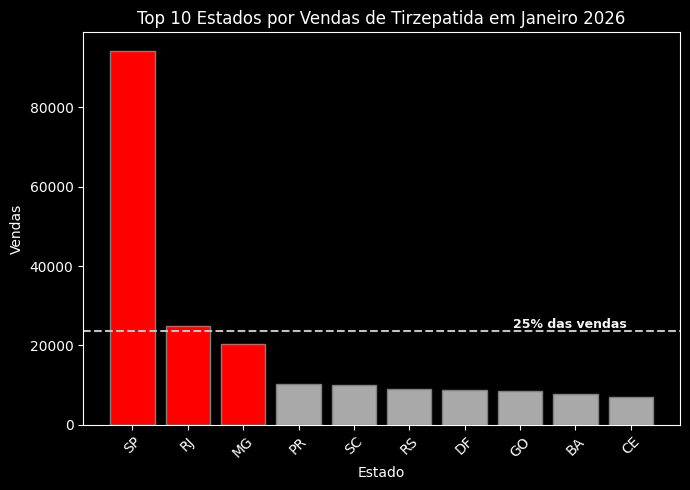

In [11]:
# Let's write below the code for the column graph
# Let's change the style of the the graph
plt.style.use('dark_background')

uf_state_top10 = uf_state.sort_values(ascending=False).head(10)
colors = ['red' if i < 3 else 'darkgray' for i in range(len(uf_state_top10))]
plt.figure(figsize=(7, 5)) 

# Plotting
plt.bar(uf_state_top10.index, uf_state_top10.values, color=colors, edgecolor='grey')

# Calculation
half_value = uf_state_top10.max() / 4
plt.axhline(y=half_value, color='silver', linestyle='--', linewidth=1.5)

# Text
plt.text(x=9, y=half_value, s='25% das vendas ', 
         color='whitesmoke', va='bottom', ha='right', fontweight='bold', fontsize=9)

plt.title('Top 10 Estados por Vendas de Tirzepatida em Janeiro 2026')
plt.xlabel('Estado')
plt.ylabel('Vendas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

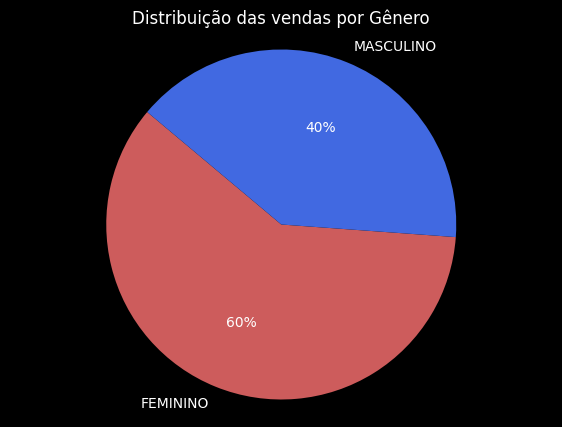

In [12]:
# Now let's see if there is more women or man using the Mounjaro in Brazil
gender_counts = filtered_df['SG_SEXO'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(gender_counts, 
        labels=gender_counts.index, 
        autopct='%1.f%%', 
        colors=['indianred','royalblue'], 
        startangle=140)

plt.title('Distribuição das vendas por Gênero')
plt.axis('equal')
plt.show()

In [13]:
# Has we saw above, there is 1576120 rows with NU_IDADE missing values... 
# I'll drop this rows with null values and then watch out for outliers first
unique_ages = filtered_df['NU_IDADE'].dropna()

outliers = filtered_df[(filtered_df['NU_IDADE'] > 110) | (filtered_df['NU_IDADE'] < 0)]
print(outliers)

        SG_UF_VENDA NO_MUNICIPIO_VENDA DS_PRINCIPIO_ATIVO  \
20263            MG       POUSO ALEGRE        TIRZEPATIDA   
46218            MA           SÃO LUÍS        TIRZEPATIDA   
48073            MA           SÃO LUÍS        TIRZEPATIDA   
66982            MG             MURIAÉ        TIRZEPATIDA   
67446            PA         ANANINDEUA        TIRZEPATIDA   
...             ...                ...                ...   
4534215          CE          FORTALEZA        TIRZEPATIDA   
4535536          CE          FORTALEZA        TIRZEPATIDA   
4535549          CE          FORTALEZA        TIRZEPATIDA   
4582752          RR          BOA VISTA        TIRZEPATIDA   
4582777          RR          BOA VISTA        TIRZEPATIDA   

                                 DS_DESCRICAO_APRESENTACAO  QT_VENDIDA  \
20263    10 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...           2   
46218    5 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X ...           1   
48073    5 MG/ML SOL INJ SC CT 4 SER PREENC V

/tmp/ipykernel_16/2666906851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['NU_IDADE'] = pd.to_numeric(filtered_df['NU_IDADE'], errors='coerce')


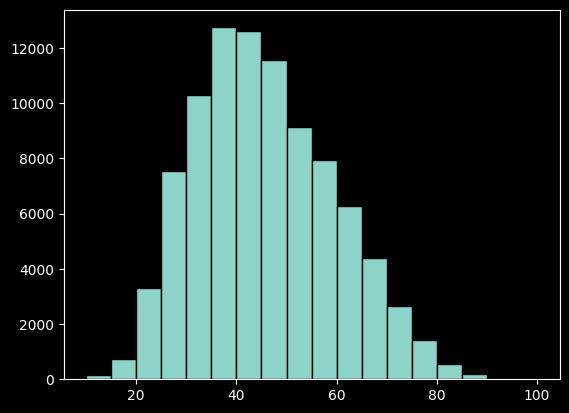

In [14]:
# Has we can see, there is outliers on the NU_IDADE column, so I need to filter before using the histogram
filtered_df['NU_IDADE'] = pd.to_numeric(filtered_df['NU_IDADE'], errors='coerce')

# Filtering for a realistic range
df_filtered = filtered_df[filtered_df['NU_IDADE'].between(10, 100)]

# Plotting
plt.hist(df_filtered['NU_IDADE'], bins=18, edgecolor='black')
plt.show()

/tmp/ipykernel_16/1316714390.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['NU_IDADE'] = pd.to_numeric(filtered_df['NU_IDADE'], errors='coerce')


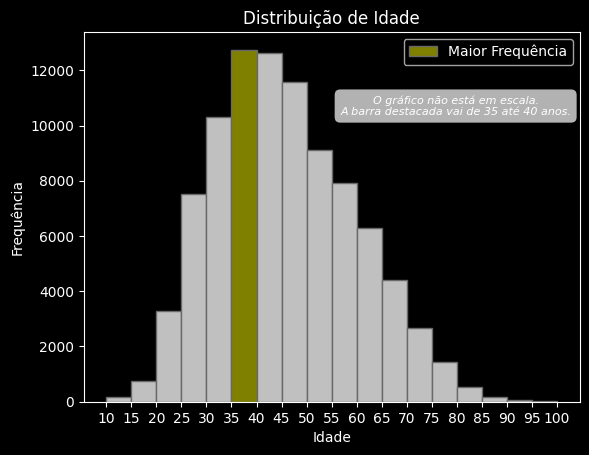

In [15]:
# Ok, now, let's do a more detailed analysis on this histogram
filtered_df['NU_IDADE'] = pd.to_numeric(filtered_df['NU_IDADE'], errors='coerce')
filtered_df = filtered_df[filtered_df['NU_IDADE'].between(10, 100)]
# Plotting
n, bins, patches = plt.hist(filtered_df['NU_IDADE'], bins=18, 
                            color='silver', edgecolor='dimgray')

# Find and Highlight the highest bar
max_bin_index = np.argmax(n)
patches[max_bin_index].set_facecolor('olive')
patches[max_bin_index].set_label('Maior Frequência')

# --- NEW: Set X-axis ticks ---
# range(start, stop, step) -> stop is exclusive, so we use 101 to include 100
plt.xticks(range(10, 101, 5)) 

# Formatting
message = ("O gráfico não está em escala.\n"
           "A barra destacada vai de 35 até 40 anos.")
plt.text(0.75, 0.8, message, 
         fontsize=8, 
         style='italic',
         ha='center', # Horizontal alignment
         va='center', # Vertical alignment
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.title('Distribuição de Idade')
plt.legend()
plt.show()

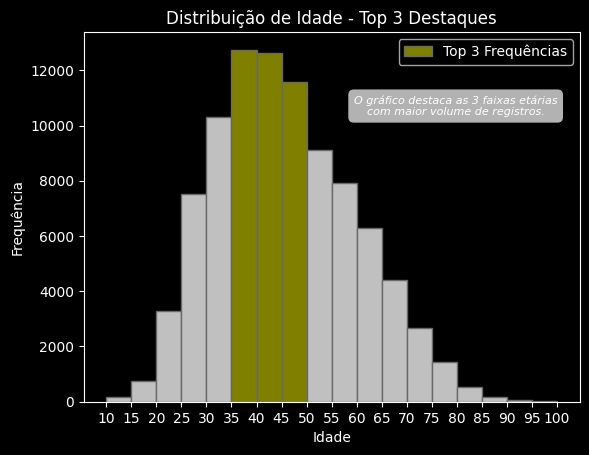

In [16]:
# 1. Cleaning and filtering
filtered_df['NU_IDADE'] = pd.to_numeric(filtered_df['NU_IDADE'], errors='coerce')
filtered_df = filtered_df[filtered_df['NU_IDADE'].between(10, 100)]

# 2. Plotting (Set a default color first)
n, bins, patches = plt.hist(filtered_df['NU_IDADE'], bins=18, 
                            color='silver', edgecolor='dimgray')

# 3. Find and Highlight the 3 highest bars
# argsort sorts from smallest to largest, so we take the last 3 [-3:]
top_3_indices = np.argsort(n)[-3:]

for i in top_3_indices:
    patches[i].set_facecolor('olive')

# Add label to only one of them for the legend (to avoid 3 duplicate entries)
patches[top_3_indices[-1]].set_label('Top 3 Frequências')

# 4. Formatting
plt.xticks(range(10, 101, 5)) 

message = ("O gráfico destaca as 3 faixas etárias\n"
           "com maior volume de registros.")

plt.text(0.75, 0.8, message, 
         fontsize=8, 
         style='italic',
         ha='center', 
         va='center', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.title('Distribuição de Idade - Top 3 Destaques')
plt.legend()
plt.show()

In [17]:
# Nice!  Now let's do more granularity here... Since of SP state has more than 25% of the sells 
# of all other 9 states, let's analyze the cities that sells the most quantities of the medication

city_tirz = (filtered_df['SG_UF_VENDA'] == 'SP') & (filtered_df['DS_PRINCIPIO_ATIVO'].str.contains('TIRZEPATIDA', case=False))
df_city_mounjaro = filtered_df[city_tirz]

# Groupby city and sum the quantity
city_sales = df_city_mounjaro.groupby('NO_MUNICIPIO_VENDA')['QT_VENDIDA'].sum()

# Get top 10
cities_sp_top10 = city_sales.sort_values(ascending=False).head()
print(cities_sp_top10)

NO_MUNICIPIO_VENDA
SÃO PAULO         38853
CAMPINAS           3093
RIBEIRÃO PRETO     2597
SANTOS             2024
SOROCABA           1701
Name: QT_VENDIDA, dtype: int64


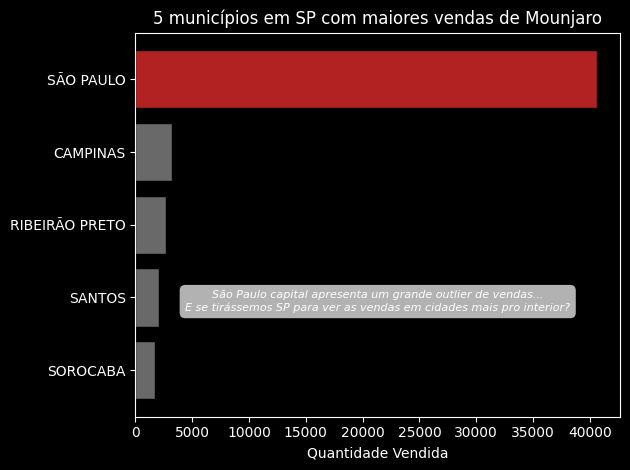

In [18]:
# Now I'll do almost the same analysis but with the cities of SP state
plt.style.use('dark_background')

city_tirz = (df['SG_UF_VENDA'] == 'SP') & (df['DS_PRINCIPIO_ATIVO'].str.contains('TIRZEPATIDA', case=False))
df_city_mounjaro = df[city_tirz]
city_sales = df_city_mounjaro.groupby('NO_MUNICIPIO_VENDA')['QT_VENDIDA'].sum()
cities_sp_top10 = city_sales.sort_values(ascending=False).head(5)

# Specify the color for the bars that are NOT highlighted
highlight_color = 'firebrick' 
original_color = 'dimgray'
colors_highlight_top = [original_color] * 4 + [highlight_color]
plt.barh(cities_sp_top10.index[::-1], cities_sp_top10.values[::-1], color=colors_highlight_top, edgecolor='black')


# Ploting the graph
message = ("São Paulo capital apresenta um grande outlier de vendas...\n"
           "E se tirássemos SP para ver as vendas em cidades mais pro interior?")
plt.text(0.5, 0.3, message, 
         fontsize=8, 
         style='italic',
         ha='center', # Horizontal alignment
         va='center', # Vertical alignment
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))
plt.xlabel('Quantidade Vendida')
plt.title('5 municípios em SP com maiores vendas de Mounjaro')
plt.tight_layout()
plt.savefig('horizontal_bar_highlighted.png')
plt.show()

In [19]:
# Drop São Paulo from the results, then sort and get the top 5
drop_spstate = city_sales.drop('SÃO PAULO').sort_values(ascending=False).head()
print(drop_spstate)

NO_MUNICIPIO_VENDA
CAMPINAS          3247
RIBEIRÃO PRETO    2660
SANTOS            2112
SOROCABA          1760
SANTO ANDRÉ       1742
Name: QT_VENDIDA, dtype: int64


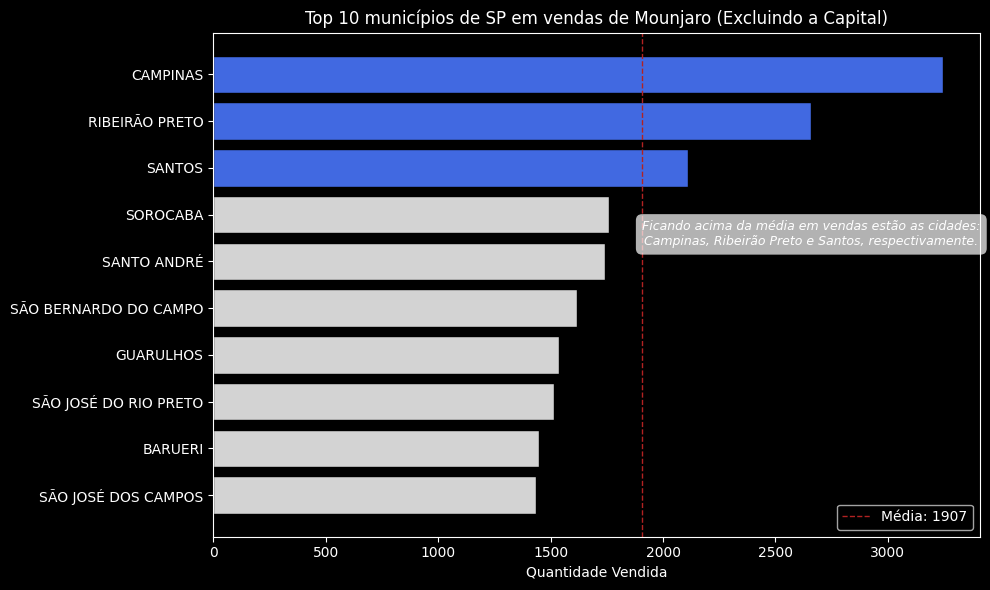

In [20]:
# 1. Filter out the capital
city_sales_no_sp = city_sales.drop('SÃO PAULO')

# 2. Get the new top 10
cities_interior_top10 = city_sales_no_sp.sort_values(ascending=False).head(10)

# 3. Prepare colors: 
# The bottom 5 bars (lower values) will be gray, the top 5 (higher values) will be blue.
# Since we plot with [::-1], the list order matches the bottom-to-top drawing.
colors = ['lightgray'] * 7 + ['royalblue'] * 3

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.barh(cities_interior_top10.index[::-1], 
         cities_interior_top10.values[::-1], 
         color=colors, 
         edgecolor='black')

# 5. Adding the Mean Line
v_mean = cities_interior_top10.mean()
plt.axvline(v_mean, color='firebrick', linestyle='--', linewidth=1, label=f'Média: {int(v_mean)}')

# Formatting
message = ("Ficando acima da média em vendas estão as cidades:\n" "Campinas, Ribeirão Preto e Santos, respectivamente.")
plt.text(0.78, 0.6, message, 
         fontsize=9, 
         style='italic',
         ha='center', # Horizontal alignment
         va='center', # Vertical alignment
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))
plt.xlabel('Quantidade Vendida')
plt.title('Top 10 municípios de SP em vendas de Mounjaro (Excluindo a Capital)')
plt.legend() # Shows the label for the mean line
plt.tight_layout()
plt.show()

In [21]:
# Exportando para CSV
filtered_df.to_csv('output.csv', index=False)

In [22]:
df.to_csv('df.csv', index=False)